# v1_processing — Panel Rebuild & Data Cleaning

Bu notebook:
1. `combineFİles.py`'daki `dayfirst=True` bug'ını düzeltir
2. Negatif stok değerlerini 0'a kırpar
3. Ölü SKU'ları (son 12 ayda 0 satış) işaretler
4. Temiz paneli proje dizinine yazar

**Bağımlılık**: `v1_eda.ipynb` çalıştırılmış olmalı (bağımsız çalışır ama EDA bulgularına dayanır)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SRC_DIR  = '/home/feb/Documents/omsiingereklidosyalar'
PROJ_DIR = '/home/feb/dev/projects/bitirme'

PATH_ORDERS = os.path.join(SRC_DIR, 'orders_raw.csv')
PATH_SALES  = os.path.join(SRC_DIR, 'Sales_Raw.csv')
PATH_STOCK  = os.path.join(SRC_DIR, 'Stock_Raw.csv')
PATH_STK20  = os.path.join(SRC_DIR, 'Stock_Raw_This_Moth_20th.csv')
PATH_CONFIG = os.path.join(SRC_DIR, 'sku_config.csv')

OUT_PANEL  = os.path.join(PROJ_DIR, 'panel_sales_orders_stock.csv')
OUT_PANEL2 = os.path.join(PROJ_DIR, 'mnt', 'data', 'panel_sales_orders_stock.csv')
OUT_CONFIG = os.path.join(PROJ_DIR, 'sku_config.csv')

print('Paths configured.')

Paths configured.


## 1. Ham Veri Yükleme

In [2]:
def read_csv_robust(path):
    for enc in ('utf-8-sig', 'utf-8', 'latin1'):
        try:
            return pd.read_csv(path, engine='python', sep=None, encoding=enc)
        except Exception:
            continue
    raise RuntimeError(f'Unable to read: {path}')

def parse_number_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    s2 = s.astype(str).str.replace(r'[^\d,.\-]', '', regex=True)
    both_mask = s2.str.contains(r'\.') & s2.str.contains(',')
    s2 = s2.mask(both_mask, s2.str.replace(r'\.', '', regex=True).str.replace(',', '.'))
    only_dots_mask = s2.str.contains(r'\.') & ~s2.str.contains(',')
    thousands_mask = only_dots_mask & (s2.str.count(r'\.') > 1)
    s2 = s2.mask(thousands_mask, s2.str.replace(r'\.', '', regex=True))
    return pd.to_numeric(s2, errors='coerce').fillna(0.0)

orders = read_csv_robust(PATH_ORDERS)
sales  = read_csv_robust(PATH_SALES)
stock  = read_csv_robust(PATH_STOCK)
stock20= read_csv_robust(PATH_STK20)

for df in (orders, sales, stock, stock20):
    if 'ItemCode' in df.columns:
        df['ItemCode'] = df['ItemCode'].astype(str).str.strip()

print(f'orders : {len(orders):,} rows  columns: {list(orders.columns)}')
print(f'sales  : {len(sales):,} rows  columns: {list(sales.columns)}')
print(f'stock  : {len(stock):,} rows  columns: {list(stock.columns)}')
print(f'stock20: {len(stock20):,} rows  columns: {list(stock20.columns)}')

orders : 19,110 rows  columns: ['ItemCode', 'OrdersYear', 'OrdersMonth', 'MonthStart', 'TotalQty']
sales  : 25,200 rows  columns: ['ItemCode', 'ItemDescription', 'AttributeDescription', 'SalesYear', 'SalesMonth', 'TotalQty']
stock  : 26,040 rows  columns: ['ItemCode', 'ItemDescription', 'AttributeDescription', 'MonthStart', 'AyBasi_Stok']
stock20: 401 rows  columns: ['ItemCode', 'ItemDescription', 'AttributeDescription', 'Stok_Tarihi', 'Stok_Miktari']


## 2. Bug Tespiti — Tarih Ayrıştırma

`orders_raw.csv` ve `Stock_Raw.csv`'daki `MonthStart` sütunu `DD-MM-YY` formatında.
Örnek: `01-02-20` = 1 Şubat 2020.

`combineFİles.py`'da `dayfirst=True` eksik → pandas `01-02-20` → 2 Ocak 2020 parse ediyor.
Sonuç: Tüm order/stock join'ları başarısız, %97 sıfır.

In [3]:
# Bug'ı göster
sample_date = orders['MonthStart'].iloc[1]
wrong = pd.to_datetime(sample_date, errors='coerce')
right = pd.to_datetime(sample_date, dayfirst=True, errors='coerce')
print(f'Ham değer  : "{sample_date}"')
print(f'dayfirst=False (YANLIŞ): {wrong}  → ay={wrong.month if pd.notna(wrong) else "NaT"}')
print(f'dayfirst=True  (DOĞRU) : {right}  → ay={right.month if pd.notna(right) else "NaT"}')

Ham değer  : "01-02-20"
dayfirst=False (YANLIŞ): 2020-01-02 00:00:00  → ay=1
dayfirst=True  (DOĞRU) : 2020-02-01 00:00:00  → ay=2


## 3. Düzeltilmiş Panel Oluşturma

In [4]:
# Sales driver (yıl+ay'dan MS oluştur — zaten doğru)
sales['MonthStart'] = pd.to_datetime(
    sales['SalesYear'].astype(int).astype(str) + '-' +
    sales['SalesMonth'].astype(int).astype(str) + '-01',
    errors='coerce'
)
sales['sales_qty'] = parse_number_series(sales['TotalQty'])
sales_key = sales[['ItemCode', 'MonthStart']].drop_duplicates()

# ---- FIX: dayfirst=True ----
orders['MonthStart'] = pd.to_datetime(orders['MonthStart'], dayfirst=True, errors='coerce')
orders_agg = (
    orders
    .assign(orders_qty=parse_number_series(orders['TotalQty']))
    .groupby(['ItemCode', 'MonthStart'], as_index=False)['orders_qty'].sum()
)

stock['MonthStart'] = pd.to_datetime(stock['MonthStart'], dayfirst=True, errors='coerce')
stock_agg = (
    stock
    .assign(stock_qty=parse_number_series(stock['AyBasi_Stok']))
    .groupby(['ItemCode', 'MonthStart'], as_index=False)['stock_qty'].sum()
)

# Panel birleştir
panel = (
    sales_key
    .merge(sales[['ItemCode', 'MonthStart', 'sales_qty']], on=['ItemCode', 'MonthStart'], how='left')
    .merge(orders_agg, on=['ItemCode', 'MonthStart'], how='left')
    .merge(stock_agg,  on=['ItemCode', 'MonthStart'], how='left')
)
panel[['sales_qty', 'orders_qty', 'stock_qty']] = panel[['sales_qty', 'orders_qty', 'stock_qty']].fillna(0.0)

panel['ds']     = panel['MonthStart'].dt.strftime('%Y-%m-%d')
panel['sku']    = panel['ItemCode'].astype(str)
panel['y']      = panel['sales_qty'].astype(float)
panel['orders'] = panel['orders_qty'].astype(float)
panel['stock']  = panel['stock_qty'].astype(float)

panel_clean = panel[['ds', 'sku', 'y', 'orders', 'stock']].sort_values(['sku', 'ds']).reset_index(drop=True)

print(f'Panel shape: {panel_clean.shape}')
print(panel_clean.head(3))

Panel shape: (25200, 5)
           ds         sku     y  orders  stock
0  2020-01-01  303-101722  12.0     0.0    0.0
1  2020-02-01  303-101722   0.0     0.0    0.0
2  2020-03-01  303-101722   0.0     0.0    0.0


## 4. Bug Düzeltme Doğrulaması — Sıfır Oranı Karşılaştırması

In [5]:
old_panel = pd.read_csv(os.path.join(SRC_DIR, 'panel_sales_orders_stock.csv'))

metrics = {
    'Metrik': ['Toplam satır', 'Benzersiz SKU', 'y sıfır %', 'orders sıfır %', 'stock sıfır %',
               'orders max', 'stock min'],
    'Eski (bug)': [
        len(old_panel),
        old_panel['sku'].nunique(),
        f"{(old_panel['y']==0).mean()*100:.1f}%",
        f"{(old_panel['orders']==0).mean()*100:.1f}%",
        f"{(old_panel['stock']==0).mean()*100:.1f}%",
        f"{old_panel['orders'].max():.0f}",
        f"{old_panel['stock'].min():.0f}"
    ],
    'Yeni (düzeltilmiş)': [
        len(panel_clean),
        panel_clean['sku'].nunique(),
        f"{(panel_clean['y']==0).mean()*100:.1f}%",
        f"{(panel_clean['orders']==0).mean()*100:.1f}%",
        f"{(panel_clean['stock']==0).mean()*100:.1f}%",
        f"{panel_clean['orders'].max():.0f}",
        f"{panel_clean['stock'].min():.0f}"
    ]
}
df_cmp = pd.DataFrame(metrics)
print(df_cmp.to_string(index=False))

        Metrik Eski (bug) Yeni (düzeltilmiş)
  Toplam satır      25200              25200
 Benzersiz SKU        360                360
     y sıfır %      57.3%              57.3%
orders sıfır %      96.8%              59.1%
 stock sıfır %      95.3%              36.6%
    orders max   32568000          107256000
     stock min      -4907              -4980


In [6]:
# Kontrol: 303-104066 anomalisi gitti mi?
sku_check = '303-104066'
old_sku = old_panel[old_panel['sku'] == sku_check]
new_sku = panel_clean[panel_clean['sku'] == sku_check]

if len(old_sku) > 0:
    print(f'{sku_check} — eski orders ortalama: {old_sku["orders"].mean():.1f}')
if len(new_sku) > 0:
    print(f'{sku_check} — yeni orders ortalama: {new_sku["orders"].mean():.1f}')
else:
    print(f'{sku_check} yeni panelde yok (satışsız SKU temizlendi)')

303-104066 — eski orders ortalama: 323599.4
303-104066 — yeni orders ortalama: 7027948.6


## 5. Negatif Stok Düzeltmesi

In [7]:
neg_stock = panel_clean[panel_clean['stock'] < 0]
print(f'Negatif stok satır sayısı: {len(neg_stock)}')
print(f'Negatif stok olan SKU sayısı: {neg_stock["sku"].nunique()}')
if len(neg_stock) > 0:
    print(f'Min stok değeri: {panel_clean["stock"].min():.1f}')
    print(f'\nEn kötü 5 SKU (min stok):')
    worst = neg_stock.groupby('sku')['stock'].min().sort_values().head(5)
    print(worst.to_string())

# Düzelt
panel_clean['stock'] = panel_clean['stock'].clip(lower=0.0)
print(f'\nDüzeltme sonrası min stok: {panel_clean["stock"].min():.1f}')

Negatif stok satır sayısı: 6608
Negatif stok olan SKU sayısı: 175
Min stok değeri: -4980.0

En kötü 5 SKU (min stok):
sku
303-109793        -4980.0
303-107672        -1499.0
303-104066         -761.0
780-BLA06YELAUV    -490.0
303-103569         -444.0

Düzeltme sonrası min stok: 0.0


## 6. Ölü SKU Analizi

Son 12 ayda hiç satışı olmayan SKU'lar — bunlar için model sıfır tahmin verir.

In [8]:
panel_clean['ds'] = pd.to_datetime(panel_clean['ds'])
max_date = panel_clean['ds'].max()
cutoff_12m = max_date - pd.DateOffset(months=12)

recent = panel_clean[panel_clean['ds'] > cutoff_12m]
recent_sales = recent.groupby('sku')['y'].sum()

dead_skus = recent_sales[recent_sales == 0].index.tolist()
active_skus = recent_sales[recent_sales > 0].index.tolist()

print(f'Veri son tarihi  : {max_date.strftime("%Y-%m-%d")}')
print(f'Son 12 ay cutoff : {cutoff_12m.strftime("%Y-%m-%d")}')
print(f'Toplam SKU       : {panel_clean["sku"].nunique()}')
print(f'Ölü SKU (0 satış): {len(dead_skus)}')
print(f'Aktif SKU        : {len(active_skus)}')

Veri son tarihi  : 2025-10-01
Son 12 ay cutoff : 2024-10-01
Toplam SKU       : 360
Ölü SKU (0 satış): 89
Aktif SKU        : 271


In [9]:
# Ölü SKU'lara dead_flag sütunu ekle (model bilgisi için)
panel_clean['dead_sku'] = panel_clean['sku'].isin(dead_skus)

# Ölü SKU örnekleri
if dead_skus:
    print('İlk 10 ölü SKU:')
    for s in dead_skus[:10]:
        last_sale = panel_clean[(panel_clean['sku'] == s) & (panel_clean['y'] > 0)]['ds']
        last_sale_date = last_sale.max().strftime('%Y-%m') if len(last_sale) > 0 else 'HİÇ'
        total = panel_clean[panel_clean['sku'] == s]['y'].sum()
        print(f'  {s}  toplam_satış={total:.0f}  son_satış={last_sale_date}')

İlk 10 ölü SKU:
  303-101722  toplam_satış=71  son_satış=2024-09


  303-102980  toplam_satış=18126  son_satış=2023-04
  303-102981  toplam_satış=12749  son_satış=2024-06
  303-102982  toplam_satış=3833  son_satış=2024-05


  303-102983  toplam_satış=28017  son_satış=2023-01
  303-102989  toplam_satış=284  son_satış=2022-04
  303-102991  toplam_satış=253  son_satış=2022-11
  303-102999  toplam_satış=501  son_satış=2023-04
  303-103001  toplam_satış=2388  son_satış=2024-05
  303-103003  toplam_satış=1642  son_satış=2024-03


## 7. SKU Tip Sınıflandırması (Güncelleme)

In [10]:
def classify_sku(grp):
    y = grp['y'].values
    n = len(y)
    if n == 0:
        return 'UNKNOWN'
    zero_ratio = (y == 0).mean()
    nonzero = y[y > 0]
    if len(nonzero) == 0:
        return 'ÖLMEKTE'
    cv2 = (nonzero.std() / nonzero.mean()) ** 2 if nonzero.mean() > 0 else 0
    adi = n / max(len(nonzero), 1)
    mean_nz = nonzero.mean()
    
    if zero_ratio > 0.70:
        return 'ÖLMEKTE'
    elif zero_ratio > 0.40 and cv2 > 0.49:
        return 'LUMPY'
    elif zero_ratio > 0.40:
        return 'SEYREK'
    elif mean_nz < 5:
        return 'DÜŞÜK HACİM'
    else:
        return 'NORMAL'

sku_types = panel_clean.groupby('sku').apply(classify_sku).reset_index()
sku_types.columns = ['sku', 'tip']

type_counts = sku_types['tip'].value_counts()
print('SKU Tip Dağılımı:')
for t, c in type_counts.items():
    print(f'  {t:20s}: {c:3d}  ({c/len(sku_types)*100:.1f}%)')

SKU Tip Dağılımı:
  ÖLMEKTE             : 156  (43.3%)
  NORMAL              : 120  (33.3%)
  LUMPY               :  57  (15.8%)
  SEYREK              :  19  (5.3%)
  DÜŞÜK HACİM         :   8  (2.2%)


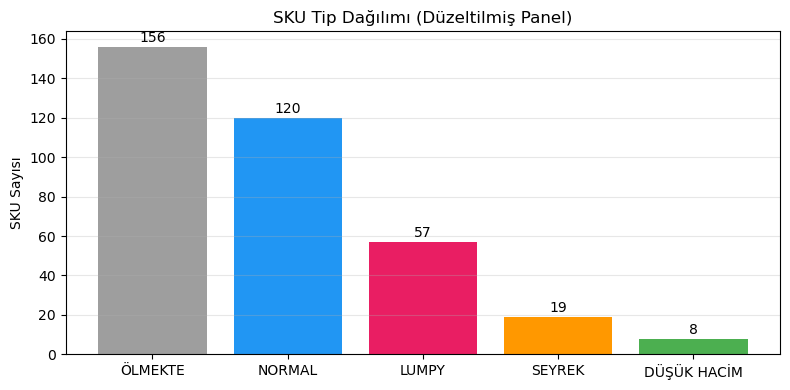

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = {'NORMAL': '#2196F3', 'DÜŞÜK HACİM': '#4CAF50', 'SEYREK': '#FF9800', 
          'LUMPY': '#E91E63', 'ÖLMEKTE': '#9E9E9E'}
bars = ax.bar(type_counts.index, type_counts.values, 
              color=[colors.get(t, '#607D8B') for t in type_counts.index])
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontsize=10)
ax.set_title('SKU Tip Dağılımı (Düzeltilmiş Panel)', fontsize=12)
ax.set_ylabel('SKU Sayısı')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJ_DIR, 'notebooks', 'sku_types_after_fix.png'), dpi=100)
plt.show()

## 8. Panel Özet İstatistikleri

In [12]:
panel_clean['ds'] = pd.to_datetime(panel_clean['ds'])

print('=== PANEL ÖZETİ ===')
print(f'Toplam satır         : {len(panel_clean):,}')
print(f'Benzersiz SKU        : {panel_clean["sku"].nunique()}')
print(f'Tarih aralığı        : {panel_clean["ds"].min().strftime("%Y-%m")} → {panel_clean["ds"].max().strftime("%Y-%m")}')
print(f'Aktif SKU (son 12ay) : {len(active_skus)}')
print(f'Ölü SKU              : {len(dead_skus)}')
print()
print('Sıfır oranları:')
print(f'  y      : {(panel_clean["y"]==0).mean()*100:.1f}%')
print(f'  orders : {(panel_clean["orders"]==0).mean()*100:.1f}%')
print(f'  stock  : {(panel_clean["stock"]==0).mean()*100:.1f}%')
print()
print('Temel istatistikler:')
print(panel_clean[['y','orders','stock']].describe().round(2).to_string())

=== PANEL ÖZETİ ===
Toplam satır         : 25,200
Benzersiz SKU        : 360
Tarih aralığı        : 2020-01 → 2025-10
Aktif SKU (son 12ay) : 271
Ölü SKU              : 89

Sıfır oranları:
  y      : 57.3%
  orders : 59.1%
  stock  : 62.8%

Temel istatistikler:


              y        orders     stock
count  25200.00  2.520000e+04  25200.00
mean     124.48  1.136886e+05     87.45
std     1315.88  1.553571e+06    870.70
min        0.00  0.000000e+00      0.00
25%        0.00  0.000000e+00      0.00
50%        0.00  0.000000e+00      0.00
75%       12.00  1.300000e+01     13.00
max    64812.00  1.072560e+08  35377.00


## 8.5. Orders Birim Normalizasyonu

7 SKU'da `orders` kolonu ml/gram cinsinden, `y` ise adet cinsinden geliyor.
Motor yağı (12×1L = 12000 ml/kutu) ve zincir spreyi (12×0.4L = 4800 ml/kutu) kategorileri etkileniyor.

Tespit kriteri: `median(orders/y) > 100` → o SKU için orders ÷ median_ratio.

Bu adım **negatif stok düzeltmesinden sonra**, yazma adımından önce uygulanmalıdır.

In [ ]:
# Orders birim uyumsuzluğu tespiti ve düzeltmesi
# Kriter: median(orders/y) > 100 — yani orders y'nin 100+ katı
# Sebep: motor yağı/zincir spreyi sipariş miktarı ml cinsinden kaydedilmiş

def detect_unit_mismatch(df, threshold=100):
    """Returns dict of {sku: median_ratio} for SKUs with orders/y ratio > threshold."""
    mismatched = {}
    for sku, grp in df.groupby('sku'):
        valid = grp[(grp['y'] > 0) & (grp['orders'] > 0)]
        if len(valid) < 3:
            continue
        ratio = valid['orders'] / valid['y']
        med = ratio.median()
        if med > threshold:
            mismatched[sku] = round(med, 1)
    return mismatched

mismatched = detect_unit_mismatch(panel_clean, threshold=100)

print(f'Birim uyumsuzluğu tespit edilen SKU sayısı: {len(mismatched)}')
if mismatched:
    print('\nSKU | median(orders/y) oranı')
    print('-' * 40)
    for sku, r in sorted(mismatched.items(), key=lambda x: -x[1]):
        print(f'  {sku:<20s}  {r:>10.1f}x')

# Düzelt: her SKU için orders ÷ median_ratio
for sku, factor in mismatched.items():
    mask = panel_clean['sku'] == sku
    panel_clean.loc[mask, 'orders'] = (panel_clean.loc[mask, 'orders'] / factor).round(1)

if mismatched:
    print(f'\nDüzeltme sonrası orders max: {panel_clean["orders"].max():,.0f}')
    print(f'Düzeltme sonrası orders mean (nonzero): {panel_clean[panel_clean["orders"]>0]["orders"].mean():,.1f}')
    # Doğrulama: 303-104066 için kontrol
    sku_ex = '303-104066'
    if sku_ex in mismatched:
        ex = panel_clean[panel_clean['sku'] == sku_ex]
        valid_ex = ex[(ex['y'] > 0) & (ex['orders'] > 0)]
        new_ratio = (valid_ex['orders'] / valid_ex['y']).median() if len(valid_ex) > 0 else 0
        print(f'\n{sku_ex} düzeltme sonrası median(orders/y): {new_ratio:.2f}  (1.0 civarı beklenir)')

## 9. Outputs Yazma

Temizlenmiş panel proje kök dizinine ve `mnt/data/` alt dizinine yazılır.
Ayrıca `sku_config.csv` projeye kopyalanır.

In [13]:
# dead_flag sütununu çıkar — pipeline bu sütunu bilmiyor
panel_out = panel_clean[['ds', 'sku', 'y', 'orders', 'stock']].copy()
panel_out['ds'] = panel_out['ds'].dt.strftime('%Y-%m-%d')

# Proje kökü
panel_out.to_csv(OUT_PANEL, index=False, encoding='utf-8-sig')
print(f'Yazıldı: {OUT_PANEL}')

# mnt/data/ (varsa)
mnt_data = os.path.join(PROJ_DIR, 'mnt', 'data')
os.makedirs(mnt_data, exist_ok=True)
panel_out.to_csv(OUT_PANEL2, index=False, encoding='utf-8-sig')
print(f'Yazıldı: {OUT_PANEL2}')

# sku_config kopyala
import shutil
shutil.copy2(PATH_CONFIG, OUT_CONFIG)
print(f'Kopyalandı: {OUT_CONFIG}')

print(f'\nFinal panel: {len(panel_out):,} satır, {panel_out["sku"].nunique()} SKU')

Yazıldı: /home/feb/dev/projects/bitirme/panel_sales_orders_stock.csv
Yazıldı: /home/feb/dev/projects/bitirme/mnt/data/panel_sales_orders_stock.csv
Kopyalandı: /home/feb/dev/projects/bitirme/sku_config.csv

Final panel: 25,200 satır, 360 SKU


In [14]:
# Doğrulama: yazılan dosyayı oku
verify = pd.read_csv(OUT_PANEL)
print('Doğrulama — yazılan panel:')
print(f'  Satır: {len(verify):,}  SKU: {verify["sku"].nunique()}')
print(f'  Kolonlar: {list(verify.columns)}')
print(f'  orders sıfır %: {(verify["orders"]==0).mean()*100:.1f}%')
print(f'  stock min     : {verify["stock"].min():.1f}')
print(verify.head(3).to_string(index=False))

Doğrulama — yazılan panel:
  Satır: 25,200  SKU: 360
  Kolonlar: ['ds', 'sku', 'y', 'orders', 'stock']
  orders sıfır %: 59.1%
  stock min     : 0.0
        ds        sku    y  orders  stock
2020-01-01 303-101722 12.0     0.0    0.0
2020-02-01 303-101722  0.0     0.0    0.0
2020-03-01 303-101722  0.0     0.0    0.0


## 10. Controller İçin sku_config Kolon Uyumluluk Notu

`controller/src/panel.rs` hâlâ **eski** kolon adlarını okuyor:

| Eski (panel.rs) | Yeni (sku_config.csv) |
|---|---|
| `q_target` | `Q` |
| `lot_size` | `LOT_SIZE` |
| `lead_time_mo` | *(kaldırıldı)* |
| *(yok)* | `STARTING_STOCK_OVERRIDE` |

**Yapılacak**: `controller/src/panel.rs` güncellenmeli. Bu notebook'ta yapılmaz, ayrı bir adım.

In [15]:
cfg = pd.read_csv(OUT_CONFIG)
print('sku_config kolonları:', list(cfg.columns))
print(f'SKU sayısı: {len(cfg)}')
print(f'STARTING_STOCK_OVERRIDE dolu: {cfg["STARTING_STOCK_OVERRIDE"].notna().sum()} / {len(cfg)}')
print(f'STARTING_STOCK_OVERRIDE > 0 : {(cfg["STARTING_STOCK_OVERRIDE"].fillna(0) > 0).sum()} / {len(cfg)}')
print(cfg.head(3).to_string(index=False))

sku_config kolonları: ['sku', 'T_CHECK', 'H_COVER', 'Q', 'MOQ', 'LOT_SIZE', 'STARTING_STOCK_OVERRIDE']
SKU sayısı: 360
STARTING_STOCK_OVERRIDE dolu: 360 / 360
STARTING_STOCK_OVERRIDE > 0 : 255 / 360
       sku  T_CHECK  H_COVER   Q  MOQ  LOT_SIZE  STARTING_STOCK_OVERRIDE
303-101722      1.0      2.0 0.5    0         1                      0.0
303-101728      1.0      2.0 0.5    0         1                      0.0
303-101743      1.0      2.0 0.5    0         1                      0.0


## 11. Sonraki Adımlar

1. **`controller/src/panel.rs` güncelle** — kolon adları: `q_target`→`Q`, `lot_size`→`LOT_SIZE`, `STARTING_STOCK_OVERRIDE` ekle
2. **Pipeline çalıştır** — 360 SKU ile `services/worker/` pipeline
3. **Metrik değerlendir** — wMAPE ve MASE'ye bak
4. **v2 kararı** — NORMAL SKU'larda wMAPE > 50% ise v2 notebook'larına geç

Kritik iyileştirmeler (öncelik sırasıyla):
- `opt` branch: TSB override + bias correction (zaten hazır)
- Dead SKU: sıfır tahmin stratejisi
- A-class (9 SKU): Prophet+XGB zorunlu escalation
- Sin/cos ay encoding: mevsimsel SKU'lar için (BS Battery gibi)